####  DSAI3301 - Data Analysis & Visualisation: Spring 2026 Individual Project

Diabetes Risk Factor Analysis (16)
- Methodology: Inferential Statistical Analysis    
- Domain: Healthcare
- Suggested Dataset: Kaggle — 'Pima Indians Diabetes Database' (768 patients, 8 health indicators).
- Suggested Dataset Link: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
- Problem Statement: Test whether glucose, BMI and age significantly differ between diabetic and non-diabetic patients.
- Suggested Techniques: Independent-samples t-test, Mann-Whitney U, logistic regression


In [1]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn jupyter


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\syeda\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

#### 1. Data Loading & Exploration

In [28]:
df = pd.read_csv('data/raw/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [29]:
print('Shape:', df.shape)

Shape: (768, 9)


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [31]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [32]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### 2. Data Cleaning

The dataset contains zero values in columns where it is biologically impossible for a zero to exist for a living patient (Glucose, BloodPressure, SkinThickness, Insulin, BMI). These are treated as missing values and replaced with NaN.

In [33]:
zeros_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[zeros_cols] = df[zeros_cols].replace(0, np.nan)

print('Missing values after replacing zeros:')
print(df.isnull().sum())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


#### Imputation Strategy

Boxplots and histograms are used to check distribution shape before deciding between mean or median imputation.

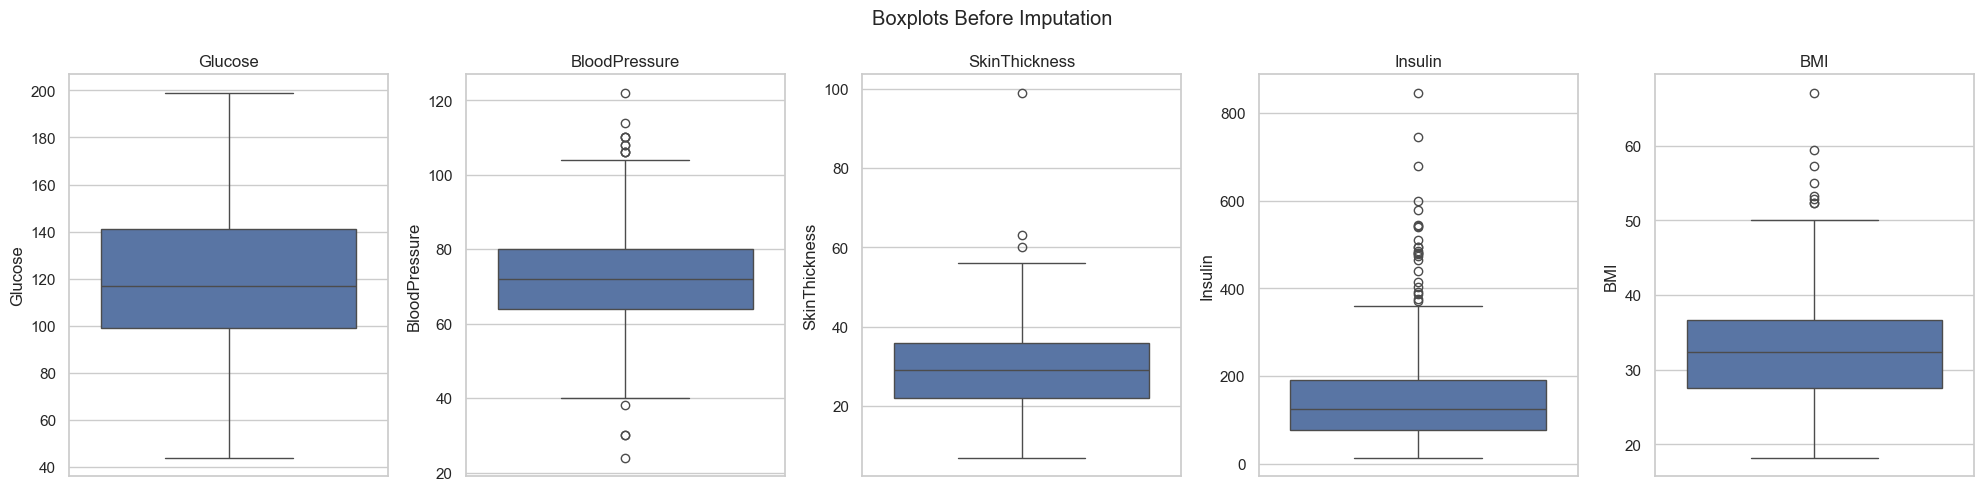

In [34]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, zeros_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.suptitle('Boxplots Before Imputation')
plt.tight_layout()
plt.savefig('figures/1_boxplots_before_imputation.png')
plt.show()

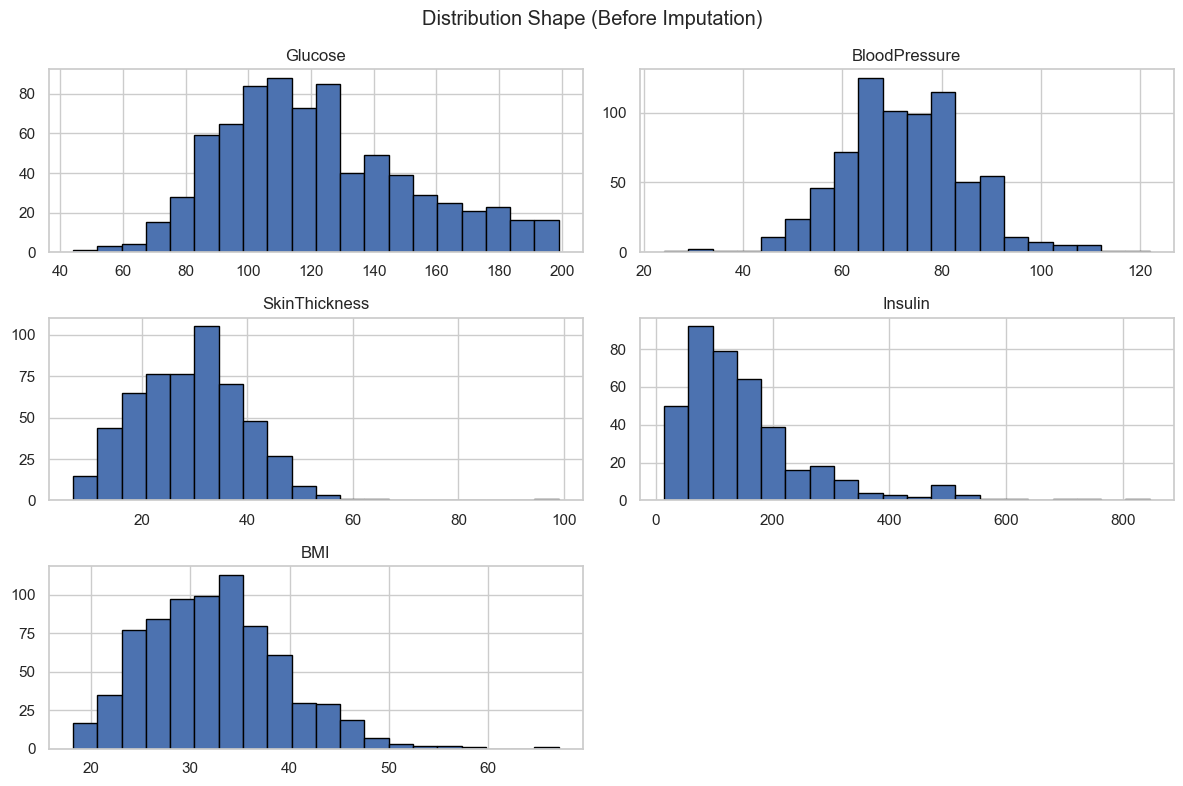

In [35]:
df[zeros_cols].hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle('Distribution Shape (Before Imputation)')
plt.tight_layout()
plt.savefig('figures/2_histograms_before_imputation.png')
plt.show()

#### Decision
All five columns show right-skewed distributions or high-end outliers, therefore median imputation is chosen as it is robust to outliers regardless of skew direction.

In [36]:
df[zeros_cols] = df[zeros_cols].fillna(df[zeros_cols].median())

print('Missing values after imputation:')
print(df.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [37]:
df.to_csv('data/processed/diabetes_cleaned.csv', index=False)
print('Cleaned dataset saved.')

Cleaned dataset saved.


#### 3. Exploratory Data Analysis (EDA)

In [38]:
print(df['Outcome'].value_counts())
print()
print(df['Outcome'].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


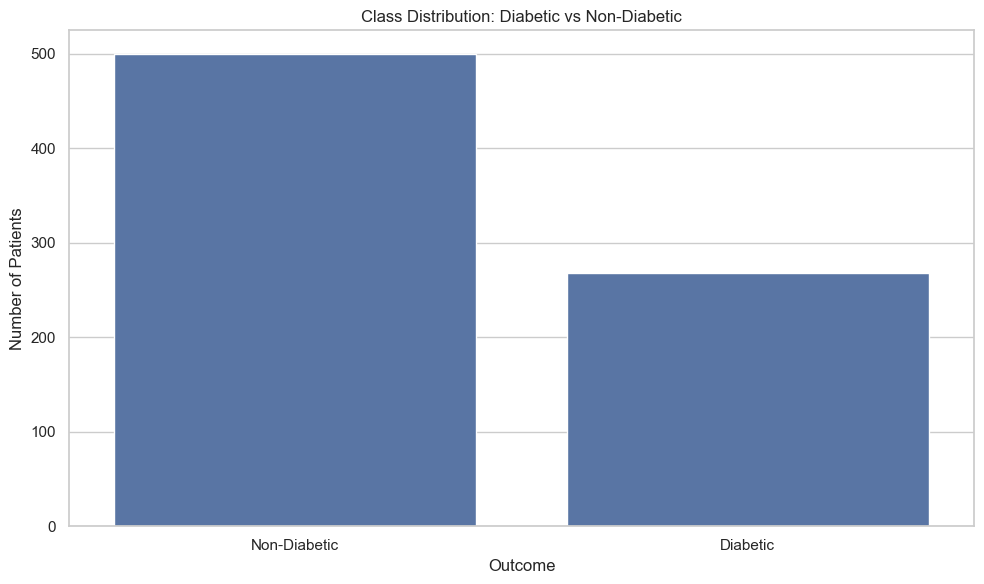

In [39]:
sns.countplot(x='Outcome', data=df)
plt.title('Class Distribution: Diabetic vs Non-Diabetic')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('figures/3_class_distribution.png')
plt.show()

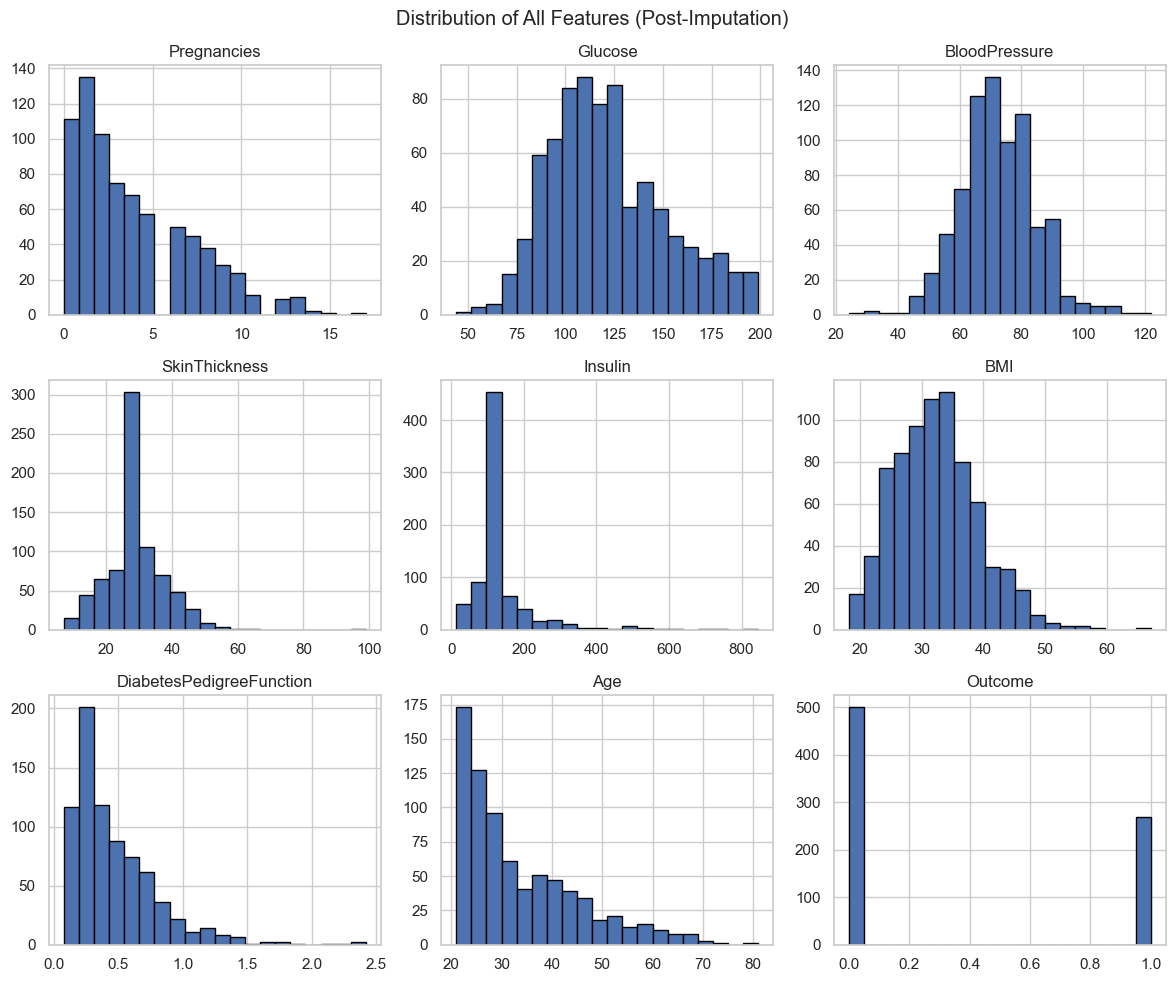

In [40]:
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of All Features (Post-Imputation)')
plt.tight_layout()
plt.savefig('figures/4_all_features_distribution.png')
plt.show()

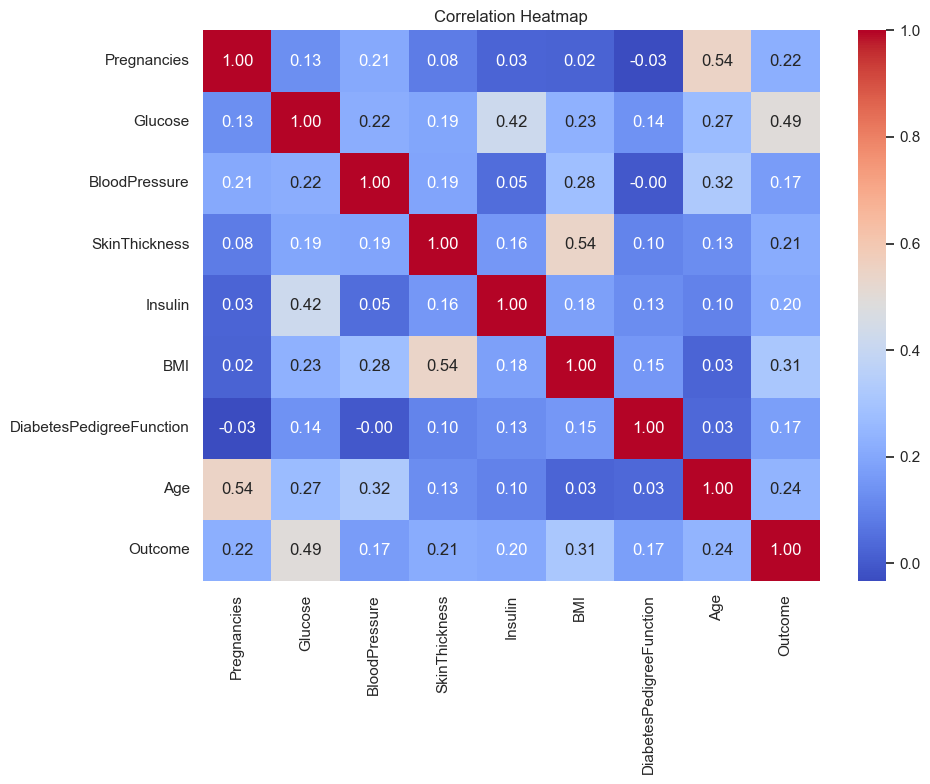

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('figures/5_correlation_heatmap.png')
plt.show()

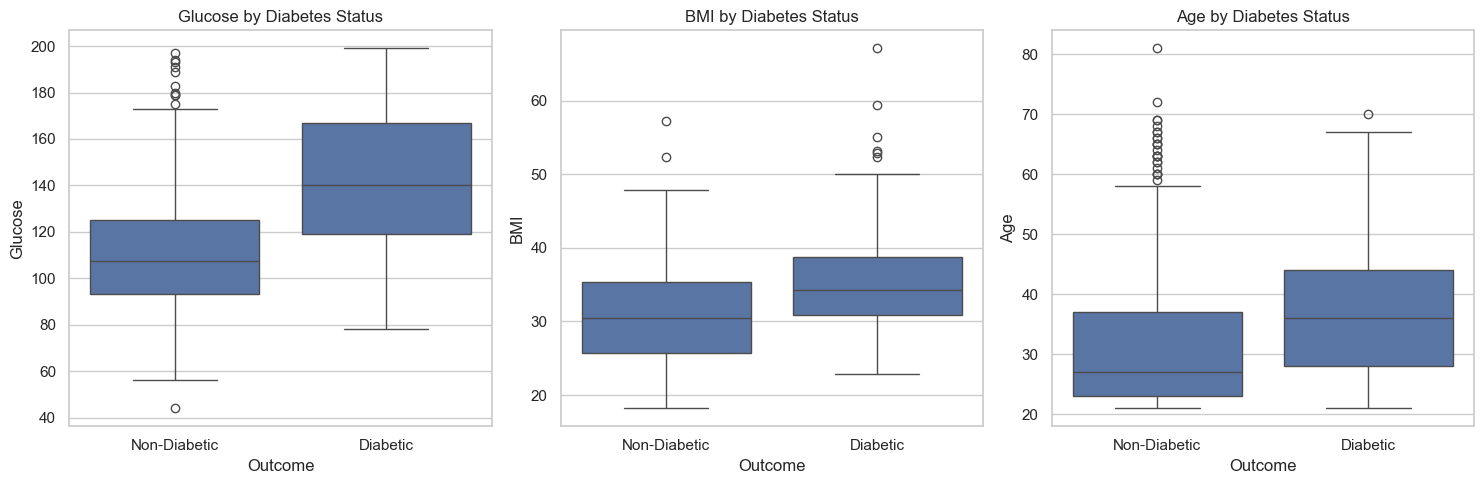

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Glucose', 'BMI', 'Age']):
    sns.boxplot(x='Outcome', y=col, data=df, ax=ax)
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
    ax.set_title(f'{col} by Diabetes Status')

plt.tight_layout()
plt.savefig('figures/6_boxplots_glucose_bmi_age.png')
plt.show()

#### 4. Inferential Statistical Analysis

##### Hypothesis Setup

For each variable (Glucose, BMI, Age) we test:

- **H₀:** There is no significant difference between diabetic and non-diabetic patients
- **H₁:** There is a significant difference between diabetic and non-diabetic patients

**Significance level:** α = 0.05

#### 4.1 Independent Samples t-test

In [43]:
diabetic     = df[df['Outcome'] == 1]
non_diabetic = df[df['Outcome'] == 0]

for col in ['Glucose', 'BMI', 'Age']:
    stat, p = ttest_ind(diabetic[col], non_diabetic[col])
    print(f'{col}:')
    print(f'  t-statistic = {stat}')
    print(f'  p-value     = {p}')
    if p < 0.05:
        print(f'  → Reject H₀ — significant difference exists\n')
    else:
        print(f'  → Fail to reject H₀ — no significant difference\n')

Glucose:
  t-statistic = 15.673795182294105
  p-value     = 3.1287190418423694e-48
  → Reject H₀ — significant difference exists

BMI:
  t-statistic = 9.09006441398665
  p-value     = 8.336902677508856e-19
  → Reject H₀ — significant difference exists

Age:
  t-statistic = 6.792688071649956
  p-value     = 2.2099754606654358e-11
  → Reject H₀ — significant difference exists



#### 4.2 Mann-Whitney U Test (Non-Parametric Confirmation)
Since real-world health data may not perfectly follow a normal distribution, Mann-Whitney U is run as a non-parametric confirmation of the t-test results. Both tests agreeing strengthens the conclusion.

In [44]:
for col in ['Glucose', 'BMI', 'Age']:
    stat, p = mannwhitneyu(diabetic[col], non_diabetic[col])
    print(f'{col}:')
    print(f'  U-statistic = {stat}')
    print(f'  p-value     = {p}')
    if p < 0.05:
        print(f'  → Reject H₀ — significant difference exists\n')
    else:
        print(f'  → Fail to reject H₀ — no significant difference\n')

Glucose:
  U-statistic = 106065.5
  p-value     = 1.507934976399154e-40
  → Reject H₀ — significant difference exists

BMI:
  U-statistic = 91917.5
  p-value     = 1.8441128048230205e-17
  → Reject H₀ — significant difference exists

Age:
  U-statistic = 92050.0
  p-value     = 1.1422001179619007e-17
  → Reject H₀ — significant difference exists



#### 4.3 Chi-Square Test

Chi-Square tests the association between two categorical variables.
Since Glucose, BMI, and Age are continuous, we first bin them into
clinically recognised categories, then test whether each category
is associated with diabetes outcome.

- H₀: There is no association between the variable group and diabetes outcome
- H₁: There is a significant association between the variable group and diabetes outcome

Significance level: α = 0.05

In [45]:
# Glucose groups — clinical standard
df['GlucoseGroup'] = pd.cut(df['Glucose'],
                             bins=[0, 99, 125, 200],
                             labels=['Normal (<100)',
                                     'Pre-Diabetic (100-125)',
                                     'Diabetic Range (>125)'])

# BMI groups — WHO standard
df['BMIGroup'] = pd.cut(df['BMI'],
                         bins=[0, 18.5, 24.9, 29.9, 70],
                         labels=['Underweight',
                                 'Normal',
                                 'Overweight',
                                 'Obese'])

# Age groups — clinical standard
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[20, 35, 50, 100],
                         labels=['Young (21-35)',
                                 'Middle (36-50)',
                                 'Older (51+)'])

print(df['GlucoseGroup'].value_counts())
print()
print(df['BMIGroup'].value_counts())
print()
print(df['AgeGroup'].value_counts())

GlucoseGroup
Diabetic Range (>125)     297
Pre-Diabetic (100-125)    279
Normal (<100)             192
Name: count, dtype: int64

BMIGroup
Obese          483
Overweight     179
Normal         102
Underweight      4
Name: count, dtype: int64

AgeGroup
Young (21-35)     498
Middle (36-50)    189
Older (51+)        81
Name: count, dtype: int64


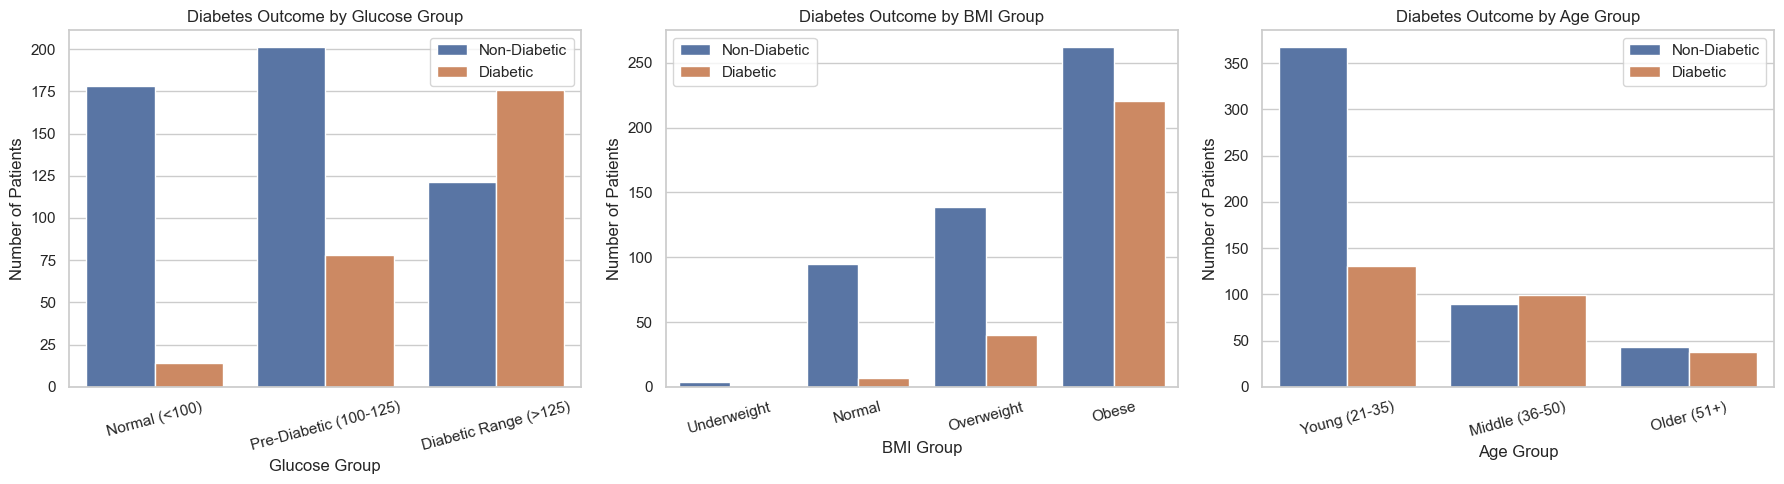

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

groups = [
    ('GlucoseGroup', 'Glucose Group',
     ['Normal (<100)', 'Pre-Diabetic (100-125)', 'Diabetic Range (>125)']),
    ('BMIGroup', 'BMI Group',
     ['Underweight', 'Normal', 'Overweight', 'Obese']),
    ('AgeGroup', 'Age Group',
     ['Young (21-35)', 'Middle (36-50)', 'Older (51+)']),
]

for ax, (col, title, order) in zip(axes, groups):
    sns.countplot(x=col, hue='Outcome', data=df, order=order, ax=ax)
    ax.set_title(f'Diabetes Outcome by {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Number of Patients')
    ax.legend(labels=['Non-Diabetic', 'Diabetic'])
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('figures/8_chisquare_groups.png')
plt.show()

In [47]:
for col, group_col in [('Glucose', 'GlucoseGroup'),
                        ('BMI',     'BMIGroup'),
                        ('Age',     'AgeGroup')]:

    contingency = pd.crosstab(df[group_col], df['Outcome'])
    contingency.columns = ['Non-Diabetic', 'Diabetic']
    print(f'--- {col} Contingency Table ---')
    print(contingency)
    print()

--- Glucose Contingency Table ---
                        Non-Diabetic  Diabetic
GlucoseGroup                                  
Normal (<100)                    178        14
Pre-Diabetic (100-125)           201        78
Diabetic Range (>125)            121       176

--- BMI Contingency Table ---
             Non-Diabetic  Diabetic
BMIGroup                           
Underweight             4         0
Normal                 95         7
Overweight            139        40
Obese                 262       221

--- Age Contingency Table ---
                Non-Diabetic  Diabetic
AgeGroup                              
Young (21-35)            367       131
Middle (36-50)            90        99
Older (51+)               43        38



In [54]:
for col, group_col in [('Glucose', 'GlucoseGroup'),
                        ('BMI',     'BMIGroup'),
                        ('Age',     'AgeGroup')]:

    contingency = pd.crosstab(df[group_col], df['Outcome'])
    chi2, p, dof, expected = chi2_contingency(contingency)

    print(f'{col}:')
    print(f'  Chi-Square = {chi2}')
    print(f'  p-value    = {p}')
    print(f'  dof        = {dof}')
    if p < 0.05:
        print(f'  → Reject H₀ — significant association exists\n')
    else:
        print(f'  → Fail to reject H₀ — no significant association\n')

Glucose:
  Chi-Square = 147.90826255817686
  p-value    = 7.623051811488307e-33
  dof        = 2
  → Reject H₀ — significant association exists

BMI:
  Chi-Square = 74.9084804674606
  p-value    = 3.7907181671390034e-16
  dof        = 3
  → Reject H₀ — significant association exists

Age:
  Chi-Square = 46.760319618202736
  p-value    = 7.01658206282625e-11
  dof        = 2
  → Reject H₀ — significant association exists



#### Chi-Square Results Summary

Glucose, BMI, and Age were each binned into clinically recognised
categories (clinical glucose ranges, WHO BMI categories, age bands)
before testing.

**Binning rationale:**
- Glucose: Normal / Pre-Diabetic / Diabetic Range — standard clinical thresholds
- BMI: Underweight / Normal / Overweight / Obese — WHO classification
- Age: Young / Middle / Older — clinical screening age bands

**Note:** Binning continuous variables into categories loses some
information. The t-test on raw continuous values is therefore the
stronger primary test — Chi-Square here provides a complementary
categorical perspective, confirming the same pattern holds when
variables are viewed as groups rather than numbers.

#### 5. Logistic Regression

Logistic regression is used to identify which variables jointly predict diabetes outcome when all features are considered together.

In [52]:
X = df.drop(columns=['Outcome', 'GlucoseGroup', 'BMIGroup', 'AgeGroup'])
y = df['Outcome']

X_const = sm.add_constant(X)
model = sm.Logit(y, X_const).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.464090
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      759
Method:                           MLE   Df Model:                            8
Date:                Fri, 26 Jun 2026   Pseudo R-squ.:                  0.2825
Time:                        21:36:19   Log-Likelihood:                -356.42
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 5.394e-56
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -9.1090      0.814    -11.197      0.000     -10.703

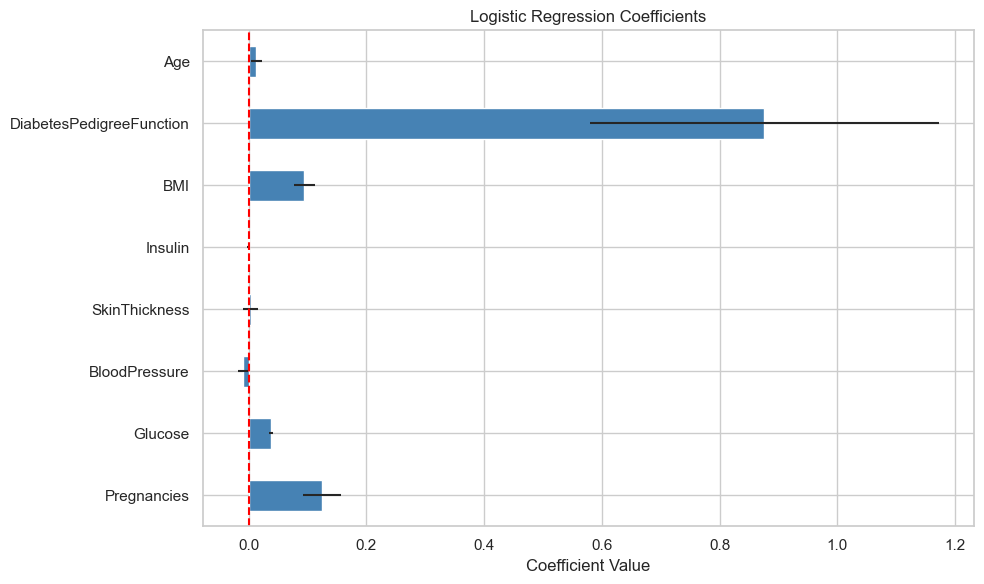

In [53]:
results = model.params[1:]
errors  = model.bse[1:]

plt.figure(figsize=(10, 6))
results.plot(kind='barh', xerr=errors, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('figures/7_logistic_regression_coefficients.png')
plt.show()

**Note:** Coefficient magnitudes are not directly comparable across variables due to differing scales. Glucose has a small coefficient (0.038) but operates over a large range (44–199), making its practical impact substantial despite appearing small on this chart. Statistical significance (p-value) is a more reliable indicator of importance than coefficient size alone.

**Significant predictors (p < 0.05):** Glucose, BMI, Pregnancies, DiabetesPedigreeFunction  
**Pseudo R² = 0.28** — the model explains ~28% of variance in diabetes outcome.

#### 6. Results Summary

| Variable | t-test | Mann-Whitney U | Logistic Regression |
|---|---|---|---|
| Glucose | p < 0.0001 | p < 0.0001 | Significant |
| BMI     | p < 0.0001 | p < 0.0001 | Significant |
| Age     | p < 0.0001 | p < 0.0001 | Not Significant |

**Key Findings:**

1. **Glucose** is the strongest risk factor: highest t-statistic (15.67), strongest correlation with Outcome (r = 0.49), and most significant predictor in logistic regression.

2. **BMI** is a consistent moderate predictor as it is significant across all three tests.

3. **Age** is significant in isolation (both t-test and Mann-Whitney U confirm p < 0.0001), however it becomes insignificant in logistic regression (p = 0.171) when all variables are considered together,  likely due to its high correlation with Pregnancies (r = 0.54).

**Conclusion:** We reject H₀ for all three variables. Glucose, BMI, and Age all significantly differ between diabetic and non-diabetic patients, directly answering the project problem statement.